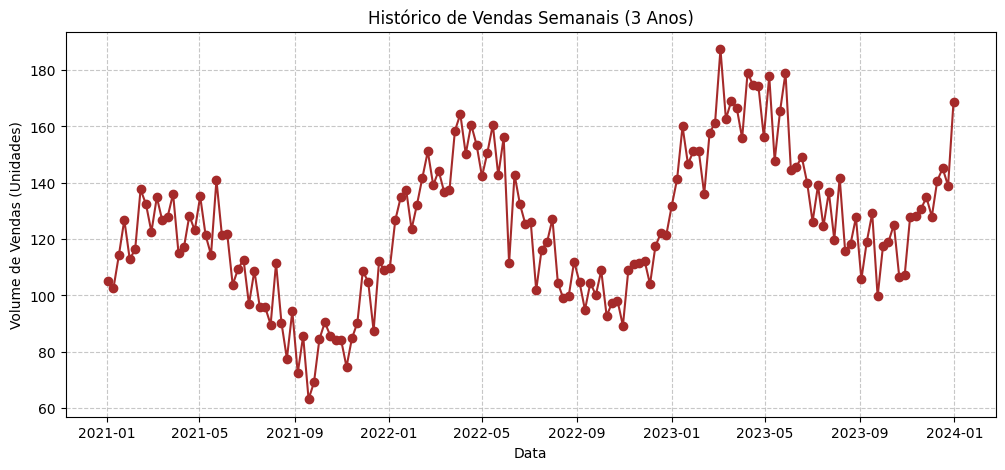

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Configurando o período de 3 anos (semanal)
np.random.seed(42)
datas = pd.date_range(start='2021-01-01', end='2023-12-31', freq='W')

# 2. Simulando vendas com sazonalidade (ex: vende mais no meio do ano/inverno)
tendencia = np.linspace(100, 150, len(datas)) # Crescimento ao longo dos anos
sazonalidade = 30 * np.sin(np.linspace(0, 3 * 2 * np.pi, len(datas))) # Ondas de alta e baixa
ruido = np.random.normal(0, 10, len(datas)) # Variações aleatórias do dia a dia

vendas = tendencia + sazonalidade + ruido

# 3. Criando a tabela de dados (DataFrame)
df = pd.DataFrame({'Data': datas, 'Vendas_Achocolatado': vendas})
df.set_index('Data', inplace=True)

# 4. Salvando os dados na nossa pasta 'data'
df.to_csv('../data/vendas_historicas.csv')

# 5. Visualizando o gráfico da série temporal
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Vendas_Achocolatado'], marker='o', linestyle='-', color='brown')
plt.title('Histórico de Vendas Semanais (3 Anos)')
plt.xlabel('Data')
plt.ylabel('Volume de Vendas (Unidades)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Verificando os primeiros dados
print("Primeiras 5 linhas do histórico:")
display(df.head())

# Resumo estatístico (Média, Desvio Padrão, Mínimo e Máximo)
print("\nResumo Estatístico das Vendas:")
display(df.describe())



Primeiras 5 linhas do histórico:


,Vendas_Achocolatado
Data,
2021-01-03,104.967142
2021-01-10,102.553970
2021-01-17,114.297381
2021-01-24,126.829984
2021-01-31,112.882213



Resumo Estatístico das Vendas:


,Vendas_Achocolatado
count,157.000000
mean,124.314945
std,25.359783
min,63.134019
25%,106.374877
50%,123.498238
75%,141.310455
max,187.414051


In [ ]:

#"Quanto vamos vender na semana que vem?"

# Previsão de demana
## Treino - 2,5 anos para captar o padrão
## Teste - ultimos 6 meses para comparativo posterior

# Modelos:

# 1. Holt-Winters (Suavização Exponencial Tripla)
# Modelo que decompõe a série e dá pesos maiores para os dados mais recentes. 
# Ele aprende o Nível, a Tendência e a Sazonalidade separadamente.
# Pressupostos: Assume que a sazonalidade e a tendência são relativamente estáveis e se repetem em ciclos fixos (ex: a cada 52 semanas).
# Vantagem: Rápido de calcular e muito mais legivel.

# 2. SARIMA (Seasonal Autoregressive Integrated Moving Average)
# Utiliza a própria defasagem (o passado influencia o futuro) 
# e a média dos erros passados para prever o próximo ponto.
# Pressupostos: 
# Estacionariedade: A média e a variância dos dados não podem mudar com o tempo (se mudarem, o 'I' do SARIMA aplica diferenças matemáticas para estabilizar).
# Resíduos: Após a previsão, o erro que sobra deve ser "Ruído Branco" (média zero, sem padrão oculto). Se sobrar padrão no erro, o modelo falhou em capturar alguma coisa.


c:\Users\marci\Documents\demand-forecasting-models\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\marci\Documents\demand-forecasting-models\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\marci\Documents\demand-forecasting-models\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


--- Métricas: Holt-Winters ---
MAE:  6.79 unidades
RMSE: 8.50 unidades
MAPE: 5.47 % 

--- Métricas: SARIMA ---
MAE:  6.95 unidades
RMSE: 8.86 unidades
MAPE: 5.55 % 



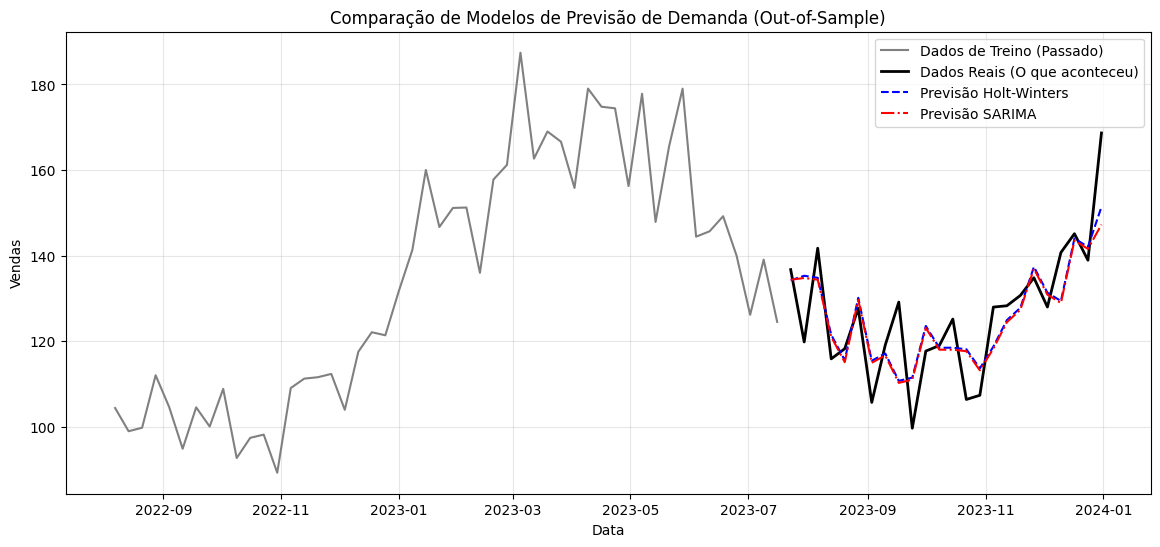

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# 1. Separando Treino (primeiros meses) e Teste (últimas 24 semanas / ~6 meses)
treino = df.iloc[:-24]
teste = df.iloc[-24:]

# 2. Modelo 1: Holt-Winters (Suavização Exponencial)
# seasonal_periods=52 (pois temos dados semanais e um ano tem 52 semanas)
modelo_hw = ExponentialSmoothing(treino['Vendas_Achocolatado'], 
                                 trend='add', 
                                 seasonal='add', 
                                 seasonal_periods=52).fit()
previsao_hw = modelo_hw.forecast(24)

# 3. Modelo 2: SARIMA (Simplificado para rodar rápido)
# order=(1,1,1) é a parte ARIMA, seasonal_order=(1,1,0,52) é a parte Sazonal
modelo_sarima = SARIMAX(treino['Vendas_Achocolatado'], 
                        order=(1, 1, 1), 
                        seasonal_order=(1, 1, 0, 52),
                        enforce_stationarity=False).fit(disp=False)
previsao_sarima = modelo_sarima.forecast(24)

# 4. Calculando as Medidas de Erro
def calcular_metricas(real, previsto, nome_modelo):
    mae = mean_absolute_error(real, previsto)
    rmse = np.sqrt(mean_squared_error(real, previsto))
    mape = mean_absolute_percentage_error(real, previsto) * 100
    print(f"--- Métricas: {nome_modelo} ---")
    print(f"MAE:  {mae:.2f} unidades")
    print(f"RMSE: {rmse:.2f} unidades")
    print(f"MAPE: {mape:.2f} % \n")

calcular_metricas(teste['Vendas_Achocolatado'], previsao_hw, "Holt-Winters")
calcular_metricas(teste['Vendas_Achocolatado'], previsao_sarima, "SARIMA")

# 5. Visualização Nível Gerencial
plt.figure(figsize=(14, 6))
plt.plot(treino.index[-50:], treino['Vendas_Achocolatado'][-50:], label='Dados de Treino (Passado)', color='grey')
plt.plot(teste.index, teste['Vendas_Achocolatado'], label='Dados Reais (O que aconteceu)', color='black', linewidth=2)
plt.plot(teste.index, previsao_hw, label='Previsão Holt-Winters', color='blue', linestyle='--')
plt.plot(teste.index, previsao_sarima, label='Previsão SARIMA', color='red', linestyle='-.')

plt.title('Comparação de Modelos de Previsão de Demanda (Out-of-Sample)')
plt.xlabel('Data')
plt.ylabel('Vendas')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# MEDIDA DE ERRO
# MAE (Erro Absoluto Médio): Em média, quantas unidades de achocolatado erramos para cima ou para baixo?
# RMSE (Raiz do Erro Quadrático Médio): Como ele eleva o erro ao quadrado, ele penaliza erros gigantes. Se errar por pouco é ok, mas errar por muito quebra a fábrica, olhamos para o RMSE.
# MAPE (Erro Percentual Absoluto Médio): Legibilidade "Nosso modelo tem um erro de 5%".

# "O Holt-Winters apresentou uma performance ligeiramente superior (MAPE 5.47%) 
# por ser mais robusto ao capturar a tendência linear e a sazonalidade aditiva da nossa série. 
# O SARIMA, embora potente, pode ter sofrido uma leve instabilidade ao tentar ajustar os parâmetros 
# de autocorrelação em um horizonte mais longo de 24 semanas."


In [ ]:
# Holt-Winters (O pragmático): Ele trabalha com Suavização Exponencial. 
# Imagine que ele olha para o passado e vai "alisando" as variações. 
# Ele foca muito na Tendência (se a linha está subindo ou descendo) e na Sazonalidade. 
# Se a tendência de crescimento que ele calculou for constante, ele vai continuar projetando aquela reta para sempre.

# SARIMA (O matemático complexo): Ele trabalha com Correlação. 
# Ele tenta entender como o valor de hoje se correlaciona com o de ontem (AR) 
# e como os erros do passado se corrigem (MA). 
# À medida que avançamos no tempo (meses 4, 5 e 6 da previsão), 
# o SARIMA vai perdendo essa "conexão" com os últimos dados reais, 
# e a fórmula matemática dele pode começar a ser mais influenciada pela média de longo prazo ou por termos de erro acumulados.

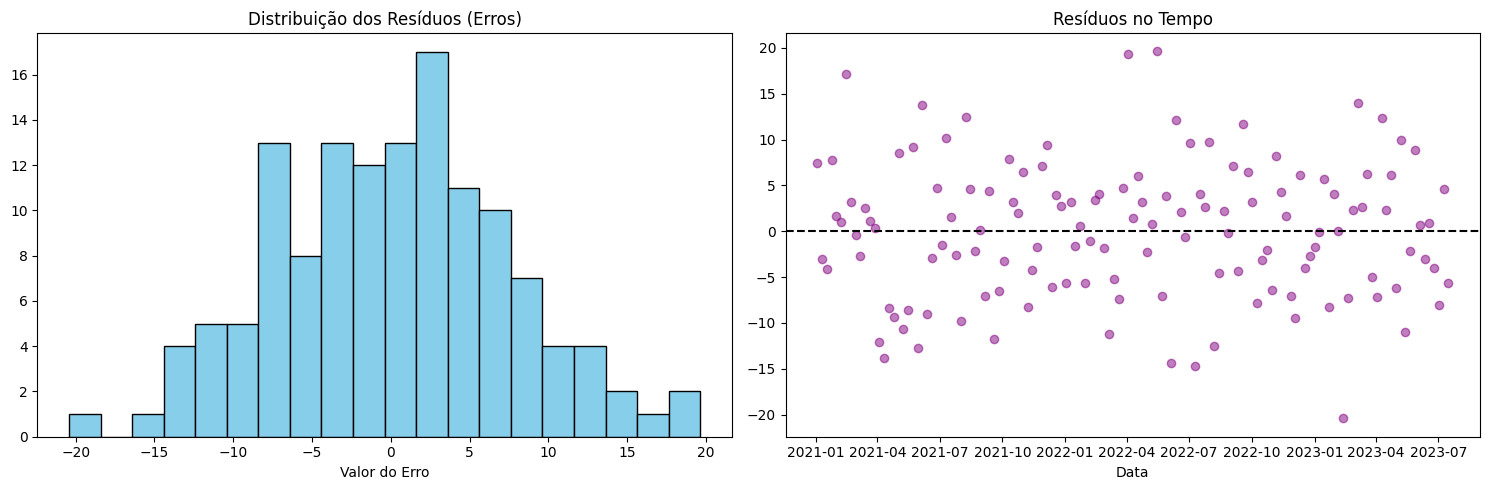

Média dos resíduos: 0.0049


In [6]:
# Verificação do modelo (está mentindo para nós?)
# Erro (Resíduo) deve ser aleatório. Se o erro tiver um padrão (ex: o modelo erra sempre para mais no frio), 
# significa que o modelo "esqueceu" de aprender algo importante.

# 1. Calculando os resíduos (O que sobrou que o modelo não explicou)
residuos = modelo_hw.resid

# 2. Criando o Painel de Diagnóstico
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Histograma dos Erros
# Esperamos uma curva de sino (Distribuição Normal) centralizada no Zero
ax[0].hist(residuos, bins=20, color='skyblue', edgecolor='black')
ax[0].set_title('Distribuição dos Resíduos (Erros)')
ax[0].set_xlabel('Valor do Erro')

# Gráfico 2: Resíduos ao longo do tempo
# Esperamos que os pontos estejam espalhados sem padrão nenhum ao redor do zero
ax[1].plot(residuos, color='purple', marker='o', linestyle='', alpha=0.5)
ax[1].axhline(y=0, color='black', linestyle='--')
ax[1].set_title('Resíduos no Tempo')
ax[1].set_xlabel('Data')

plt.tight_layout()
plt.show()

# 3. Teste de média zero
print(f"Média dos resíduos: {residuos.mean():.4f}")